# CUSTOM HEATMAP – CoEVFold:4D (CoEV Rank): unexplained and explained coevolution from a pre-computed matrix

This version starts from a coevolution matrix calculated elsewhere (for example PyCoM, CCMpred, plmc or a saved GREMLIN matrix) instead of running MMseqs2 and GREMLIN. Upload the matrix in the first cell, then run the structure cells as usual.

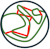

This notebook, compares a pdb structure (or two) to find unexplained and explained coevolution. It is derived from ColabDesign, as well as custom comparison and pymol related scripts.

This can be used most significantly for visualising and assessing the number of monomers that make up a homo-multimer, or if a protein is predicted by coevolution to form multimers and where. Therefore facilitating mutagenesis experiments.

It has the following inputs:

1. Sequence.
2. Pdb structures (multimer or not)

And the following outputs:

1. Coevolution and contact matrix of each setup compared

2. A PSE file of the multimer pdb, with coevolution contacts only explained by it, not the monomer.

In [ ]:
#@title Upload a pre-computed coevolution matrix (e.g. PyCoM, CCMpred, plmc, GREMLIN)
#@markdown Use this instead of running the alignment and GREMLIN. The matrix must cover the same sequence as your
#@markdown monomer / multimer structures (one row and column per residue, in sequence order).
#@markdown
#@markdown **Accepted files**
#@markdown - an L × L matrix: `.npy`, `.npz`, `.csv`, `.tsv`, `.txt`, or a CCMpred `.mat` file
#@markdown - a pair list with three columns `i j score` (`.csv`, `.tsv`, `.txt`)
#@markdown - a plmc couplings file (`-c` output, six columns: `i A_i j A_j 0 score`)
#@markdown
#@markdown PyCoM matrices can be saved from Python with `numpy.save("matrix.npy", matrix)` and uploaded here.
#@markdown ---
jobname = "custom" #@param {type:"string"}
#@markdown Optional, but recommended: the protein sequence the matrix was calculated for (used for labels and checks).
sequence = "" #@param {type:"string"}
#@markdown Residue numbering in pair lists / plmc files.
PAIR_LIST_NUMBERING = "1-based" #@param ["1-based", "0-based"]
#@markdown Apply the average product correction (APC). Untick if your matrix is already APC-corrected
#@markdown (check the documentation of the source; CCMpred output is APC-corrected by default).
APPLY_APC = True #@param {type:"boolean"}
#@markdown Scores are converted to Z-scores exactly as in the GREMLIN version of the notebook, so the same thresholds apply.

import os, io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import squareform

try:
    from google.colab import files
    _up = files.upload()
    matrix_file = next(iter(_up.keys()))
except Exception:
    matrix_file = globals().get("MATRIX_FILE", "")      # outside Colab: set MATRIX_FILE first
assert matrix_file and os.path.exists(matrix_file), "No matrix file uploaded."
print("Matrix file:", matrix_file)


def _read_table(path):
    txt = open(path).read()
    lines = [l for l in txt.splitlines() if l.strip() and not l.lstrip().startswith(("#", ">"))]
    sep = "," if lines[0].count(",") >= 1 else None
    rows = [re.split(r"\s+", l.strip()) if sep is None else [x.strip() for x in l.split(",")] for l in lines]
    # drop a header row of non-numbers
    def isnum(x):
        try:
            float(x); return True
        except ValueError:
            return False
    if not isnum(rows[0][0]):          # header line (first field is not a number)
        rows = rows[1:]
    return rows


def load_matrix(path):
    low = path.lower()
    if low.endswith(".npy"):
        return np.load(path, allow_pickle=False).astype(float), "L × L matrix (.npy)"
    if low.endswith(".npz"):
        z = np.load(path, allow_pickle=False)
        key = list(z.keys())[0]
        return z[key].astype(float), f"L × L matrix (.npz, array '{key}')"
    rows = _read_table(path)
    ncol = {len(r) for r in rows}
    n = len(rows)
    if len(ncol) == 1 and ncol.pop() == n:                       # square: dense matrix
        return np.array(rows, dtype=float), "L × L matrix (text)"
    width = len(rows[0])
    off = 1 if PAIR_LIST_NUMBERING == "1-based" else 0
    if width == 6:                                               # plmc couplings: i A_i j A_j 0 score
        I = [int(r[0]) - off for r in rows]; J = [int(r[2]) - off for r in rows]; S = [float(r[5]) for r in rows]
        kind = "plmc couplings file"
    elif width >= 3:                                             # pair list: i j score
        I = [int(float(r[0])) - off for r in rows]; J = [int(float(r[1])) - off for r in rows]; S = [float(r[2]) for r in rows]
        kind = "pair list (i j score)"
    else:
        raise ValueError("Could not recognise the file format.")
    L = max(max(I), max(J)) + 1
    M = np.zeros((L, L))
    M[I, J] = S; M[J, I] = S
    return M, kind


M, kind = load_matrix(matrix_file)
assert M.ndim == 2 and M.shape[0] == M.shape[1], f"Matrix must be square, got {M.shape}"
M = np.nan_to_num((M + M.T) / 2.0)          # symmetric
np.fill_diagonal(M, 0.0)
L = M.shape[0]
print(f"Read {kind}: L = {L}")

sequence = re.sub("[^A-Z:]", "", sequence.upper())
if sequence:
    seq_flat = sequence.replace(":", "")
    if len(seq_flat) != L:
        print(f"WARNING: the sequence has {len(seq_flat)} residues but the matrix has {L}; check they match.")
else:
    seq_flat = ""
query_sequence = sequence
seq = seq_flat
u_sequences = [s for s in sequence.split(":") if s] if sequence else []


def normalize(x):
    x = stats.boxcox(x - np.amin(x) + 1.0)[0]
    return (x - np.mean(x)) / np.std(x)

# same steps as the GREMLIN notebook: raw -> APC -> Box-Cox -> Z-score, on the upper triangle
raw_sq = M.copy()
if APPLY_APC:
    ap = raw_sq.sum(0, keepdims=True) * raw_sq.sum(1, keepdims=True) / raw_sq.sum()
    apc_sq = raw_sq - ap
else:
    apc_sq = raw_sq
np.fill_diagonal(apc_sq, 0.0)
i_idx, j_idx = np.triu_indices(L, k=1)
mtx = {"i": i_idx, "j": j_idx,
       "raw": raw_sq[i_idx, j_idx], "apc": apc_sq[i_idx, j_idx],
       "zscore": normalize(apc_sq[i_idx, j_idx]), "len": L}
coev_mtx = pd.DataFrame({"i": mtx["i"], "j": mtx["j"], "zscore": mtx["zscore"]})
pd_mtx = pd.DataFrame({k: mtx[k] for k in ("i", "j", "raw", "apc", "zscore")})
depthratio = float("nan")      # not known for an imported matrix

def plot_mtx(mtx):
    m = np.full((mtx["len"], mtx["len"]), np.nan)
    m[mtx["i"], mtx["j"]] = mtx["zscore"]; m[mtx["j"], mtx["i"]] = mtx["zscore"]
    plt.figure(figsize=(8, 8))
    plt.title(f"Co-Evolution Matrix (imported, Z-score): {os.path.basename(matrix_file)}")
    plt.imshow(m, cmap="Blues", vmin=0.5, vmax=3)
    if ":" in query_sequence:
        b = len(query_sequence.split(":")[0]); plt.axvline(b); plt.axhline(b)
    plt.xlabel("Protein Amino acids"); plt.grid(False)
    plt.savefig(f"co-ev{jobname}.png"); plt.show()

plot_mtx(mtx)
print(f"{len(coev_mtx):,} residue pairs; Z-score range {coev_mtx.zscore.min():.2f} to {coev_mtx.zscore.max():.2f}. "
      "Continue with the structure upload cells below.")


In [ ]:
# @title Install PyMOL {"display-mode":"form"}
!python -m pip install --upgrade pip
!pip install tr-rosetta-pytorch
!apt-get install pymol

In [ ]:
from google.colab import files
import os

uploaded = files.upload()
filename = next(iter(uploaded.keys()))
#@title Upload the MONOMER pdb file with the correct chain length
jobname = os.path.splitext(filename)[0]
print(f"Job name: {jobname}")

In [ ]:
from google.colab import files
import os
#@title (optional)Upload the MULTIMER pdb file with the correct chain length
#@markdown Tick box if youd like to see your multimers 'multimer only' explaiend coevolution
multimer =True # @param {type:"boolean"}
if multimer == True:
  uploaded1 = files.upload()
  filename1 = next(iter(uploaded1.keys()))


In [ ]:
!pip install biopython matplotlib numpy


In [ ]:
from Bio.PDB import PDBParser
import numpy as np
import matplotlib.pyplot as plt

# Load and parse the first PDB file
pdb_filename = next(iter(uploaded))
parser = PDBParser()
structure = parser.get_structure('structure', pdb_filename)

# Extract chains from the structure and initialize the first chain
chains = list(structure.get_chains())
first_chain_residues = []
chain_length = 0

# Extract alpha-carbon (CA) atoms from the first chain
for residue in chains[0]:
    if 'CA' in residue:
        first_chain_residues.append(residue['CA'].get_coord())
        chain_length += 1

# Initialize the contact map matrix for the first chain
contact_map = np.zeros((chain_length, chain_length))

# Set cutoff distance in Angstroms
cutoff_distance = 12.0

# Calculate contact map for the first chain
for i in range(chain_length):
    for j in range(i + 1, chain_length):
        distance = np.linalg.norm(first_chain_residues[i] - first_chain_residues[j])
        if distance < cutoff_distance:
            contact_map[i, j] += 1
            contact_map[j, i] += 1

# Initialize aggregated contact map across all chains
num_chains = len(chains)
aggregated_contact_map = np.zeros_like(contact_map)

# Aggregate contact maps across all chains
for chain1 in chains:
    for chain2 in chains:
        for i in range(chain_length):
            residue1 = list(chain1)[i]
            for j in range(i + 1, chain_length):
                residue2 = list(chain2)[j]
                if 'CA' in residue1 and 'CA' in residue2:
                    coord1 = residue1['CA'].get_coord()
                    coord2 = residue2['CA'].get_coord()
                    distance = np.linalg.norm(coord1 - coord2)
                    if distance < cutoff_distance:
                        aggregated_contact_map[i, j] += 1
                        aggregated_contact_map[j, i] += 1

# Binarize the aggregated contact map
aggregated_contact_map = np.where(aggregated_contact_map != 0, 1, 0)

# Plot and save the aggregated contact map
plt.figure(figsize=(8, 8))
plt.imshow(aggregated_contact_map, cmap='Greys', origin='upper')
plt.title(f'Aggregated Contact Map for {pdb_filename}')
plt.xlabel('Residue Index')
plt.ylabel('Residue Index')
plt.show()
plt.savefig(f'Aggregated Contact Map for {pdb_filename}.jpg', dpi=300)

# Load and parse the second PDB file
if multimer == True :
  pdb_filename1 = next(iter(uploaded1))
  structure1 = parser.get_structure('structure', pdb_filename1)

# Check if the structure is a multimer
  chains1 = list(structure1.get_chains())
  first_chain_residues1 = []
  chain_length1 = 0
  for residue1 in chains1[0]:
        if 'CA' in residue1:
            first_chain_residues1.append(residue1['CA'].get_coord())
            chain_length1 += 1
        contact_map1 = np.zeros((chain_length1, chain_length1))

        for i in range(chain_length1):
          for j in range(i + 1, chain_length1):
              distance1 = np.linalg.norm(first_chain_residues1[i] - first_chain_residues1[j])
              if distance1 < cutoff_distance:
                  contact_map1[i, j] += 1
                  contact_map1[j, i] += 1

  num_chains1 = len(chains1)
  aggregated_contact_map1 = np.zeros_like(contact_map1)

  # Aggregate contact maps across all chains
  for chain3 in chains1:
      for chain4 in chains1:
          for i in range(chain_length1):
              residue1 = list(chain3)[i]
              for j in range(i + 1, chain_length1):
                    residue2 = list(chain4)[j]
                    if 'CA' in residue1 and 'CA' in residue2:
                        coord1 = residue1['CA'].get_coord()
                        coord2 = residue2['CA'].get_coord()
                        distance1 = np.linalg.norm(coord1 - coord2)
                        if distance1 < cutoff_distance:
                            aggregated_contact_map1[i, j] += 1
                            aggregated_contact_map1[j, i] += 1

  aggregated_contact_map1 = np.where(aggregated_contact_map1 != 0, 1, 0)
  plt.figure(figsize=(8, 8))
  plt.imshow(aggregated_contact_map1, cmap='Greys', origin='upper')
  plt.title(f'Aggregated Contact Map for {pdb_filename1}')
  plt.xlabel('Residue Index')
  plt.ylabel('Residue Index')
  plt.show()


In [ ]:
#@title Input model contact maps compared to Coevolution
import numpy as np
from scipy.signal import correlate2d
import matplotlib.pyplot as plt

# Load the data
coev_mtx.to_csv("coevolution.txt", sep='\t', index=False, header=False)
df = pd.read_csv('coevolution.txt', delimiter='\t', header=None, names=['row', 'column', 'value'])

import pandas as pd
import numpy as np

# Load the data back into a DataFrame
df = pd.read_csv('coevolution.txt', delimiter='\t', header=None, names=['row', 'column', 'value'])


# Convert row and column to integers
df['row'] = df['row'].astype(int)
df['column'] = df['column'].astype(int)

# Find the matrix size based on the maximum row and column values
max_row = df['row'].max()
max_column = df['column'].max()
matrix_size = max(max_row, max_column)

# Initialize the matrix with zeros
matrix = np.zeros((matrix_size, matrix_size))

# Populate the matrix with values from the DataFrame
for _, row in df.iterrows():
    r = int(row['row']) - 1  # Explicitly cast to integer
    c = int(row['column']) - 1  # Explicitly cast to integer
    value = row['value']

    # Assign the value to the matrix
    matrix[r, c] = value
    matrix[c, r] = value  # Ensure symmetry by filling both [r, c] and [c, r]

# Set diagonal values to 0
np.fill_diagonal(matrix, 0)

# The final matrix is now stored in the variable 'matrix'
coev_truematrix = matrix

np.savetxt('aggregated_contact_map.txt', aggregated_contact_map, fmt='%d', delimiter='\t')
np.savetxt('coevolution_contact_map.txt', coev_truematrix, fmt='%d', delimiter='\t')

def pad_matrix(matrix, target_shape):
    # Create an empty matrix of the target shape
    padded_matrix = np.zeros(target_shape)

    # Compute the padding sizes (only pad at the end)
    end_y = matrix.shape[0]
    end_x = matrix.shape[1]

    # Place the matrix at the start, pad at the end
    padded_matrix[:end_y, :end_x] = matrix
    return padded_matrix

matrix1 = coev_truematrix
matrix2 = aggregated_contact_map
if multimer == True:
  matrix3 = aggregated_contact_map1

# Find the best alignment
# Define the target shape (use the shape of the larger matrix)
target_shape = (max(matrix1.shape, matrix2.shape))

# Pad matrices
padded_matrix1 = pad_matrix(matrix1, target_shape)
padded_matrix2 = pad_matrix(matrix2, target_shape)
if multimer == True:
  padded_matrix3 = pad_matrix(matrix3, target_shape)

normalized_matrix1 = padded_matrix1
normalized_matrix2 = padded_matrix2
if multimer == True:
  normalized_matrix3 = padded_matrix3
plt.figure(figsize=(8, 8))
plt.imshow(normalized_matrix1, cmap='Blues', alpha=0.5, interpolation='none', vmin =0.5 , vmax =3)
# Plot second matrix
plt.imshow(normalized_matrix2, cmap='Greys', alpha=0.2, interpolation='none')
plt.title('CoEvolution over Contact map Monomer 12A')
plt.xlabel('Residue Index')
plt.ylabel('Residue Index')
plt.show()
plt.figure(figsize=(8, 8))
plt.imshow(normalized_matrix1, cmap='Blues', alpha=0.5, interpolation='none', vmin =0.5 , vmax =3)
# Plot second matrix
if multimer == True:
  plt.imshow(normalized_matrix3, cmap='Greys', alpha=0.2, interpolation='none')
  plt.title('CoEvolution over Contact map Multimer 12A')
  plt.xlabel('Residue Index')
  plt.ylabel('Residue Index')
  plt.show()
import numpy as np
from scipy.stats import pearsonr

# Ensure matrices are of the same size
if normalized_matrix1.shape != normalized_matrix2.shape:
    raise ValueError("Matrices must have the same dimensions to compute correlation.")
if multimer == True:
  if normalized_matrix1.shape != normalized_matrix3.shape:
      raise ValueError("Matrices must have the same dimensions to compute correlation.")
super0 = (normalized_matrix1)*(normalized_matrix1)
super = (normalized_matrix1)*(normalized_matrix1) * normalized_matrix2 #here is the point its changed to be a new matrix from contact map - we can remove that
super3 = normalized_matrix1
super3[normalized_matrix2 == 1] = 0
if multimer == True:
  super2 = (normalized_matrix1)*(normalized_matrix1) * normalized_matrix3
plt.figure(figsize=(8, 8))
if multimer == False:
  plt.imshow(super3, cmap='Reds', alpha=1, interpolation='none', vmin =1, vmax =3)
  plt.title('CoEvolution not explained by Monomer')
# Plot second matrix
if multimer == True:
  plt.imshow(super, cmap='Blues', alpha=1, interpolation='none', vmin =0.5, vmax =5)
  plt.imshow(super2, cmap='Reds', alpha=0.5, interpolation='none', vmin =0, vmax =5)
  plt.title('CoEvolution and Contact maps 10A Blues- Monomer explained Reds -Multimer explained')
plt.xlabel('Residue Index')
plt.ylabel('Residue Index')
plt.show()
plt.savefig(f'CoEvolution Compared.jpg', dpi=300)
np.savetxt('super_contact_map.txt', super, delimiter='\t')
if multimer == True:
  np.savetxt('super1_contact_map.txt', super2, delimiter='\t')
import numpy as np
import pandas as pd

matrix1 = super
if multimer == True:
  matrix2 = super2

# Threshold value
threshold = 0

# Function to create a list of residues from a matrix
def find_residues_above_threshold(matrix, threshold):
    residues = []
    n = matrix.shape[0]
    for i in range(n):
        for j in range(n):
            if matrix[i, j] > threshold:
                residues.append((i+1, j+1 , matrix[i, j]))  # (i+1, j+1) to match 1-based index
    return residues

# Get residues above the threshold in both matrices
residues_matrix1 = find_residues_above_threshold(matrix1, threshold)
residues_matrix0 = find_residues_above_threshold(super0, threshold)
if multimer == True:
  matrix2 = super2
  residues_matrix2 = find_residues_above_threshold(matrix2, threshold)

# Convert to DataFrames for easier comparison
df_matrix1 = pd.DataFrame(residues_matrix1, columns=['i', 'j', 'value'])
df_matrix0 = pd.DataFrame(residues_matrix0, columns=['i', 'j', 'value'])
if multimer == True:
  df_matrix2 = pd.DataFrame(residues_matrix2, columns=['i', 'j', 'value'])
if multimer == True:
# Merge DataFrames to find rows that are in df_matrix2 but not in df_matrix1
  df_diff = pd.merge(df_matrix2, df_matrix1, on=['i', 'j'], how='left', suffixes=('', '_matrix1'))
  df_diff = df_diff[df_diff['value_matrix1'].isna()].drop(columns=['value_matrix1'])

# Rename columns for clarity
  df_diff.columns = ['i', 'j', 'value_in_matrix2']
  df_diff = pd.merge(df_diff, coev_mtx, on=['i', 'j'], how='left')

# Replace 'value_in_matrix2' with 'zscore' from coev_mtx
  df_diff['value_in_matrix2'] = df_diff['zscore']

# Drop the zscore column if you only want value_in_matrix2
  df_diff = df_diff.drop(columns=['zscore'])
  df_diff.columns = ["A", "B", "Score"]
  df_diff = df_diff[df_diff['Score'] >= 1]
  df_diff = df_diff.dropna(subset=['Score'])
  df = df_diff.copy()
  df = df.add([1,1,0])
  df = df.sort_values('Score',ascending=False)
  df = df.reset_index()
  del df['index']
  df.to_csv('sorted_file.csv', sep=' ', index=False)
  calc_coev = coev_mtx.copy()
  calc_coev.columns = ["A", "B", "Score"]
  calc_coev = calc_coev[calc_coev['Score'] > 1]
  calc_coev = calc_coev.dropna(subset=['Score'])
  df_matrix1.columns = ["A", "B", "Score"]
  df_matrix1 = df_matrix1[df_matrix1['Score'] >= 1]
  df_matrix1 = df_matrix1.dropna(subset=['Score'])
  df_matrix2.columns = ["A", "B", "Score"]
  df_matrix2 = df_matrix2[df_matrix2['Score'] >= 1]
  df_matrix2 = df_matrix2.dropna(subset=['Score'])
  num_rows = len(calc_coev )
  num_rows1 = len(df_matrix1)
  num_rows2 = len(df_matrix2)
  num_rows3 = len(df)
  print("ALL interactions:", num_rows)
  print("MONOMER interactions:", num_rows1)
  print("MULTIMER interactions:", num_rows2)
  print("Coevolution explained by Monomer:", (num_rows1/num_rows)*100,'%')
  print("Coevolution explained by Multimer:", (num_rows2/num_rows)*100,'%')
  with open('output.txt', 'w') as file:
      file.write(f"Inter-molecular interactions explained only by Multimer\n")
      file.write(f"{df}\n")
      file.write(f"ALL interactions: {num_rows}\n")
      file.write(f"MONOMER interactions: {num_rows1}\n")
      file.write(f"MULTIMER interactions: {num_rows2}\n")
      file.write(f"Coevolution explained by Monomer: {(num_rows1/num_rows)*100}%\n")
      file.write(f"Coevolution explained by Multimer: {(num_rows2/num_rows)*100}%\n")
else:
    df_diff = pd.merge(df_matrix0, df_matrix1, on=['i', 'j'], how='left', suffixes=('', '_matrix0'))
    df_diff = df_diff[df_diff['value_matrix0'].isna()].drop(columns=['value_matrix0'])
    df_diff.columns = ['i', 'j', 'value_in_matrix0']
    df_diff = pd.merge(df_diff, coev_mtx, on=['i', 'j'], how='left')
    df_diff['value_in_matrix0'] = df_diff['zscore']
    df_diff = df_diff.drop(columns=['zscore'])
    df_diff.columns = ["A", "B", "Score"]
    df_diff = df_diff[df_diff['Score'] >= 1]
    df_diff = df_diff.dropna(subset=['Score'])
    df = df_diff.copy()
    df = df.add([1,1,0])
    df = df.sort_values('Score',ascending=False)
    df = df.reset_index()
    del df['index']
    df.to_csv('UnexplainedCoevolution.csv', sep=' ', index=False)



In [ ]:
print('Inter-molecular interactions explained only by Multimer')
print(df.sort_values(by='Score', ascending=False).head(51))

In [ ]:
#@title Top-L/5 precision vs relative Z: monomer-explained and multimer-explained coevolution
#@markdown Run after the cells above (needs `coev_mtx` and the uploaded monomer / multimer files; the sequence is found automatically).
#@markdown
#@markdown **Monomer-explained** – all coevolution pairs ranked by Z; the top L/5 above each threshold are scored against monomer contacts.
#@markdown **Multimer-explained** – pairs the monomer explains are removed first; the top L/5 of what is left above each threshold
#@markdown are scored against **inter-chain** contacts in the multimer. Nothing about the multimer is used to choose these pairs.
#@markdown
#@markdown Thresholds are given as a fraction of the maximum Z (Z / Z<sub>max</sub>, 0 → 1), so proteins can be compared on one scale,
#@markdown as in the benchmark (precision vs Z, with the number of pairs left). A second panel ranks pairs against their distance in the structure.
#@markdown ---
CONTACT_ATOM = "CB"      #@param ["CB", "CA"]
#@markdown CB = Cβ (Cα for Gly), the definition used in the 18-complex benchmark.
CONTACT_CUTOFF_A = 12.0  #@param {type:"number"}
MIN_SEQ_SEPARATION = 6   #@param {type:"integer"}
TOP_FRACTION = "L/5"     #@param ["L/10", "L/5", "L/2", "L"]
REL_Z_STEP = 0.02        #@param {type:"number"}
#@markdown Best-precision and "first reaches 0.8" are only reported where at least this many pairs are left (1 pair gives 0 or 100%).
MIN_PAIRS_FOR_PRECISION = 3 #@param {type:"integer"}
#@markdown Ranking-vs-distance panel uses pairs with Z at or above this (CoEVRank keeps Z ≥ 1).
Z_MIN_FOR_DISTANCE = 1.0 #@param {type:"number"}
#@markdown Pairs where either residue is missing from a structure cannot be judged; leave ticked to exclude them.
EXCLUDE_UNRESOLVED = True #@param {type:"boolean"}
#@markdown Leave blank to use the files uploaded above.
MONOMER_FILE = ""  #@param {type:"string"}
MULTIMER_FILE = "" #@param {type:"string"}
PROTEIN_LABEL = "" #@param {type:"string"}
#@markdown The sequence is detected automatically (alignment query, then input cell, then structure). Only fill this to override it.
QUERY_SEQUENCE = "" #@param {type:"string"}
#@markdown Each run is appended to this file, so running MlaD, SpoIIIE and the tail protein in turn builds one table.
SUMMARY_CSV = "coevrank_relZ_summary.csv" #@param {type:"string"}
SAVE_PNG = True     #@param {type:"boolean"}
AUTO_DOWNLOAD = True #@param {type:"boolean"}

import os, gzip, math, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom

# ----------------------------------------------------------------------------- structure reading
_AA3 = {"ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E","GLY":"G","HIS":"H",
        "ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P","SER":"S","THR":"T","TRP":"W",
        "TYR":"Y","VAL":"V","MSE":"M","SEC":"C","PYL":"K","HSD":"H","HSE":"H","HSP":"H","HID":"H",
        "HIE":"H","HIP":"H","CYX":"C"}

def _open(path):
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path)

def _add_atom(chains, ch, resid, resn, atom, xyz, alt):
    if alt not in ("", " ", ".", "?", "A", "1"):
        return
    if resn not in _AA3 or atom not in ("CA", "CB"):
        return
    res = chains.setdefault(ch, {})
    r = res.setdefault(resid, {"aa": _AA3[resn]})
    r.setdefault(atom, xyz)

def read_structure(path):
    """-> {chain: [(aa, CA xyz, CB xyz or None), ...]} in residue order, first model only."""
    chains = {}
    low = path.lower().replace(".gz", "")
    with _open(path) as fh:
        if low.endswith(".cif") or low.endswith(".mmcif"):
            cols, in_loop, model0 = [], False, None
            for line in fh:
                if line.startswith("_atom_site."):
                    cols.append(line.strip().split(".", 1)[1]); in_loop = True; continue
                if in_loop and cols and (line.startswith("ATOM") or line.startswith("HETATM")):
                    v = line.split()
                    d = dict(zip(cols, v))
                    mdl = d.get("pdbx_PDB_model_num", "1")
                    model0 = model0 or mdl
                    if mdl != model0:
                        continue
                    ch = d.get("auth_asym_id", d.get("label_asym_id"))
                    resid = (int(d.get("auth_seq_id", d.get("label_seq_id", "0"))), d.get("pdbx_PDB_ins_code", "?"))
                    _add_atom(chains, ch, resid, d.get("auth_comp_id", d.get("label_comp_id")),
                              d.get("auth_atom_id", d.get("label_atom_id")).strip('"'),
                              np.array([float(d["Cartn_x"]), float(d["Cartn_y"]), float(d["Cartn_z"])]),
                              d.get("label_alt_id", "."))
                elif in_loop and cols and line.startswith(("#", "loop_")):
                    if chains: break
        else:
            for line in fh:
                if line.startswith("ENDMDL"):
                    break
                if not line.startswith(("ATOM", "HETATM")):
                    continue
                _add_atom(chains, line[21], (int(line[22:26]), line[26]), line[17:20].strip(),
                          line[12:16].strip(),
                          np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])]),
                          line[16])
    out = {}
    for ch, res in chains.items():
        rows = [(r["aa"], r.get("CA"), r.get("CB")) for _, r in sorted(res.items()) if "CA" in r]
        if rows:
            out[ch] = rows
    return out

# ----------------------------------------------------------------------------- query <-> chain mapping
def _align(q, t, match=2, mismatch=-1, gap=-2):
    """Semi-global alignment (end gaps free). Returns {query_idx: target_idx} for aligned pairs."""
    if t in q:                      # chain is an exact piece of the query (e.g. a truncated construct)
        s = q.index(t)
        return {s + k: k for k in range(len(t))}
    if q in t:
        s = t.index(q)
        return {k: s + k for k in range(len(q))}
    n, m = len(q), len(t)
    H = np.zeros((n + 1, m + 1))
    P = np.zeros((n + 1, m + 1), dtype=np.int8)     # 0 diag, 1 up (skip query residue), 2 left (skip target residue)
    tb = np.frombuffer(t.encode(), dtype=np.uint8)
    for i in range(1, n + 1):
        diag = H[i - 1, :-1] + np.where(tb == ord(q[i - 1]), match, mismatch)
        up = H[i - 1, 1:] + gap
        best = np.where(diag >= up, diag, up)
        ptr = np.where(diag >= up, 0, 1).astype(np.int8)
        row, prow = H[i], P[i]
        for j in range(1, m + 1):
            left = row[j - 1] + gap
            if left > best[j - 1]:
                row[j] = left; prow[j] = 2
            else:
                row[j] = best[j - 1]; prow[j] = ptr[j - 1]
    i, j = n, int(np.argmax(H[n]))
    k = int(np.argmax(H[:, m]))
    if H[k, m] > H[i, j]:
        i, j = k, m
    mp = {}
    while i > 0 and j > 0:
        p = P[i, j]
        if p == 0:
            mp[i - 1] = j - 1; i -= 1; j -= 1
        elif p == 1:
            i -= 1
        else:
            j -= 1
    return mp

def chain_coords(struct, segments, atom, min_identity=0.5):
    """For every chain, assign it to the query segment it matches best and return
    {chain: (L_total, 3) coords with NaN where unresolved}, plus a report."""
    offsets = np.cumsum([0] + [len(s) for s in segments])
    L = offsets[-1]
    out, report = {}, []
    for ch, rows in struct.items():
        tseq = "".join(r[0] for r in rows)
        best = None
        for k, seg in enumerate(segments):
            mp = _align(seg, tseq)
            ident = np.mean([seg[a] == tseq[b] for a, b in mp.items()]) if mp else 0
            cov = len(mp) / len(seg)
            if best is None or ident * cov > best[0]:
                best = (ident * cov, k, mp, ident, cov)
        score, k, mp, ident, cov = best
        if ident < min_identity:
            report.append(f"  chain {ch}: {len(rows)} res, no query match (identity {ident:.0%}) - ignored")
            continue
        xyz = np.full((L, 3), np.nan)
        for a, b in mp.items():
            aa, ca, cb = rows[b]
            c = ca if (atom == "CA" or cb is None) else cb
            xyz[offsets[k] + a] = c
        out[ch] = xyz
        report.append(f"  chain {ch}: {len(rows)} res -> query segment {k + 1}, "
                      f"identity {ident:.0%}, covers {cov:.0%} of the segment")
    return out, report

# ----------------------------------------------------------------------------- inputs from the notebook
def _first(*names):
    for n in names:
        v = globals().get(n)
        if isinstance(v, str) and v and os.path.exists(v):
            return v
    return None

mono_path = MONOMER_FILE or _first("pdb_filename", "filename")
multi_path = MULTIMER_FILE or _first("pdb_filename1", "filename1")
assert mono_path, "No monomer structure found - upload it above or set MONOMER_FILE."
assert multi_path, "No multimer structure found - upload it above (tick 'multimer') or set MULTIMER_FILE."

# ---- sequence: detected automatically (first match wins) ----------------------------------
#  1. QUERY_SEQUENCE below, if you type one in (use ":" between chains of a heteromer)
#  2. the query sequence of the alignment GREMLIN was run on (exactly matches the coevolution numbering)
#  3. the sequence typed into the input cell
#  4. the longest chain in the uploaded structures
def _clean(x):
    return "".join(c for c in str(x).upper() if c.isalpha() or c == ":")

def _a3m_query():
    if "seqs" in globals() and len(globals()["seqs"]):
        return _clean(globals()["seqs"][0]), "alignment query (seqs[0])"
    import glob
    hits = sorted(glob.glob("*/msa.a3m"), key=os.path.getmtime, reverse=True)
    for path in hits:
        with open(path) as fh:
            for line in fh:
                if line.startswith(">"):
                    q = "".join(c for c in next(fh) if c.isupper())
                    return q, f"alignment query ({path})"
    return "", ""

segments, seq_source = [], ""
if QUERY_SEQUENCE.strip():
    segments, seq_source = [s for s in _clean(QUERY_SEQUENCE).split(":") if s], "QUERY_SEQUENCE"
if not segments:
    q, src = _a3m_query()
    if q:
        lens = globals().get("u_lengths")
        if lens and sum(lens) == len(q) and len(lens) > 1:      # heteromer: split at chain boundaries
            cuts = np.cumsum([0] + list(lens))
            segments = [q[a:b] for a, b in zip(cuts[:-1], cuts[1:])]
        else:
            segments = [q]
        seq_source = src
if not segments:
    typed = globals().get("u_sequences") or _clean(globals().get("query_sequence", globals().get("sequence", ""))).split(":")
    segments = [s.upper() for s in typed if s]
    seq_source = "input cell" if segments else ""
if not segments:
    cand = []
    for pth in (mono_path, multi_path):
        for ch, rows in read_structure(pth).items():
            cand.append(("".join(r[0] for r in rows), f"chain {ch} of {os.path.basename(pth)}"))
    sq, seq_source = max(cand, key=lambda t: len(t[0]))
    segments = [sq]
    print("NOTE: sequence taken from the structure. This is only correct if the structure covers the whole "
          "query that GREMLIN was run on, with no missing residues.")
query = "".join(segments)
L = len(query)
max_idx = int(max(coev_mtx.iloc[:, 0].max(), coev_mtx.iloc[:, 1].max()))
if max_idx >= L:
    raise ValueError(f"The coevolution matrix runs to position {max_idx + 1} but the detected sequence "
                     f"({seq_source}) has only {L} residues. Paste the sequence GREMLIN was run on into QUERY_SEQUENCE.")
print(f"Sequence: {L} residues, from {seq_source}")
label = PROTEIN_LABEL or os.path.splitext(os.path.basename(mono_path))[0]

cm = coev_mtx.copy()
cm.columns = ["i", "j", "z"]
cm["i"] = cm["i"].astype(int); cm["j"] = cm["j"].astype(int)
cm = cm[(cm["j"] - cm["i"]).abs() >= MIN_SEQ_SEPARATION]
cm = cm[(cm["i"] < L) & (cm["j"] < L)]

print(f"{label}: query length L = {L} ({len(segments)} segment(s)); {len(cm):,} coevolution pairs with |i-j| >= {MIN_SEQ_SEPARATION}")
mono_xyz, rep1 = chain_coords(read_structure(mono_path), segments, CONTACT_ATOM)
multi_xyz, rep2 = chain_coords(read_structure(multi_path), segments, CONTACT_ATOM)
print(f"Monomer  {os.path.basename(mono_path)}:"); print("\n".join(rep1))
print(f"Multimer {os.path.basename(multi_path)}:"); print("\n".join(rep2))
assert mono_xyz, "No chain in the monomer file matches the query sequence."
assert len(multi_xyz) >= 2, "The multimer file needs at least two chains that match the query."

# ----------------------------------------------------------------------------- distance maps
def distance_maps(coords):
    """min distance within any one chain, and min distance between any two different chains (symmetric)."""
    chs = list(coords)
    L_ = next(iter(coords.values())).shape[0]
    intra = np.full((L_, L_), np.inf); inter = np.full((L_, L_), np.inf)
    resolved = np.zeros(L_, bool)
    for a in chs:
        resolved |= ~np.isnan(coords[a][:, 0])
    for x in range(len(chs)):
        for y in range(x, len(chs)):
            A, B = coords[chs[x]], coords[chs[y]]
            d = np.nan_to_num(np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(-1)), nan=np.inf)
            if x == y:
                intra = np.minimum(intra, d)
            else:
                inter = np.minimum(inter, np.minimum(d, d.T))
    return intra, inter, resolved

mono_intra_d, mono_inter_d, mono_res = distance_maps(mono_xyz)
mono_d = np.minimum(mono_intra_d, mono_inter_d)          # anything inside the monomer file
_, multi_inter_d, multi_res = distance_maps(multi_xyz)

I, J = cm["i"].to_numpy(), cm["j"].to_numpy()
cm["d_mono"] = mono_d[I, J]
cm["d_inter"] = multi_inter_d[I, J]
cm["mono"] = cm["d_mono"] < CONTACT_CUTOFF_A
cm["inter"] = cm["d_inter"] < CONTACT_CUTOFF_A
cm["resolved"] = mono_res[I] & mono_res[J] & multi_res[I] & multi_res[J]
n_unres = int((~cm["resolved"]).sum())
if EXCLUDE_UNRESOLVED:
    cm = cm[cm["resolved"]]
cm = cm.sort_values("z", ascending=False).reset_index(drop=True)

z_max = float(cm["z"].max())
cm["rel_z"] = cm["z"] / z_max
un = cm[~cm["mono"]].reset_index(drop=True)              # coevolution the monomer cannot explain

frac = {"L/10": 10, "L/5": 5, "L/2": 2, "L": 1}[TOP_FRACTION]
N = max(1, L // frac)

# ----------------------------------------------------------------------------- precision vs relative Z
def fmt_p(p):
    return "n/a" if p != p else (f"{p:.2e}" if p < 1e-3 else f"{p:.3f}")

def top_stats(df, positive, n):
    top = df.head(n)
    k, n_ = int(top[positive].sum()), len(top)
    Npop, K = len(df), int(df[positive].sum())
    bg = K / Npop if Npop else float("nan")
    prec = k / n_ if n_ else float("nan")
    p = hypergeom.sf(k - 1, Npop, K, n_) if n_ and K else float("nan")
    return dict(n=n_, hits=k, precision=prec, background=bg,
                enrichment=(prec / bg) if bg else float("nan"), p=p, pool=Npop, pool_pos=K)

steps = np.round(np.arange(0, 1.0001, REL_Z_STEP), 4)
curve = []
for name, df, pos in (("monomer", cm, "mono"), ("multimer", un, "inter")):
    bg = df[pos].mean() if len(df) else float("nan")
    for t in steps:
        cand = df[df["rel_z"] >= t]
        top = cand.head(N)
        n_ = len(top); k = int(top[pos].sum())
        curve.append({"set": name, "rel_z": t, "abs_z": round(t * z_max, 3), "candidates": len(cand),
                      "top_n_used": n_, "hits": k, "precision": (k / n_) if n_ else np.nan,
                      "background": bg})
curve = pd.DataFrame(curve)

s_mono = top_stats(cm, "mono", N)            # rel_z = 0: plain top-L/5
s_multi = top_stats(un, "inter", N)

def first_reach(name, level):
    c = curve[(curve["set"] == name) & (curve["top_n_used"] >= MIN_PAIRS_FOR_PRECISION) & (curve["precision"] >= level)]
    return float(c["rel_z"].iloc[0]) if len(c) else np.nan

def best(name):
    c = curve[(curve["set"] == name) & (curve["top_n_used"] >= MIN_PAIRS_FOR_PRECISION)]
    if not len(c): return np.nan, np.nan
    r = c.loc[c["precision"].idxmax()]
    return float(r["precision"]), float(r["rel_z"])

# rank vs distance (Spearman), on the pairs CoEVRank keeps (Z >= Z_MIN_FOR_DISTANCE)
from scipy.stats import spearmanr
def rank_dist(df, col):
    sub = df[(df["z"] >= Z_MIN_FOR_DISTANCE) & np.isfinite(df[col])]
    if len(sub) < 3: return np.nan, np.nan, len(sub)
    r, p = spearmanr(sub["z"], sub[col])
    return r, p, len(sub)
rho_m, p_m, n_m = rank_dist(cm, "d_mono")
rho_x, p_x, n_x = rank_dist(un, "d_inter")

print("\n" + "=" * 82)
print(f"Contacts: {CONTACT_ATOM} within {CONTACT_CUTOFF_A:g} Å, |i-j| >= {MIN_SEQ_SEPARATION}; top {TOP_FRACTION} = {N} pairs; "
      f"max Z = {z_max:.2f}" + (f"; {n_unres} pairs with an unresolved residue excluded" if EXCLUDE_UNRESOLVED else ""))
print("-" * 82)
for name, s, extra in (("MONOMER-explained ", s_mono, "all pairs, scored against monomer contacts"),
                       ("MULTIMER-explained", s_multi, "monomer-explained pairs removed, scored against inter-chain contacts")):
    pb, tb = best(name.split("-")[0].lower())
    t8 = first_reach(name.split("-")[0].lower(), 0.8)
    print(f"{name}  ({extra})")
    print(f"   top {TOP_FRACTION} with no threshold: {s['hits']}/{s['n']} = {s['precision']:.0%}   "
          f"background {s['background']:.1%}   {s['enrichment']:.1f}x   p = {fmt_p(s['p'])}")
    print(f"   best precision {pb:.0%} at Z >= {tb:.2f} x max;  precision >= 0.8 first reached at "
          + ("not reached" if t8 != t8 else f"Z >= {t8:.2f} x max (Z = {t8 * z_max:.2f})"))
print(f"Rank vs distance (Spearman, pairs with Z >= {Z_MIN_FOR_DISTANCE:g}):  monomer ρ = {rho_m:.2f} (n = {n_m}, p = {fmt_p(p_m)});  "
      f"unexplained vs inter-chain ρ = {rho_x:.2f} (n = {n_x}, p = {fmt_p(p_x)})")
print("   (negative ρ = higher-ranked pairs are closer in the structure)")
print("=" * 82)

show = curve[np.isclose((curve["rel_z"] / 0.1) % 1, 0) | np.isclose((curve["rel_z"] / 0.1) % 1, 1)]
tab = show.pivot(index="rel_z", columns="set", values=["precision", "top_n_used", "candidates"])
tab.columns = [f"{a}_{b}" for a, b in tab.columns]
tab.insert(0, "abs_Z", (tab.index * z_max).round(2))
for c_ in [c for c in tab.columns if c.startswith(("top_n_used", "candidates"))]:
    tab[c_] = tab[c_].astype("Int64")
print("\nTop-L/5 precision by relative Z threshold:")
print(tab[["abs_Z", "precision_monomer", "top_n_used_monomer", "candidates_monomer",
           "precision_multimer", "top_n_used_multimer", "candidates_multimer"]]
      .to_string(float_format=lambda v: f"{v:.2f}"))

# per-pair table: top L/5 of each set
def pair_table(df, dcol, set_name):
    t = df.head(N).copy()
    t.insert(0, "rank", np.arange(1, len(t) + 1))
    t["set"] = set_name
    t["res_i"] = t["i"] + 1; t["res_j"] = t["j"] + 1
    t["aa_i"] = [query[x] for x in t["i"]]; t["aa_j"] = [query[x] for x in t["j"]]
    t["distance_A"] = t[dcol].round(1)
    t["contact"] = t[dcol] < CONTACT_CUTOFF_A
    return t[["set", "rank", "res_i", "aa_i", "res_j", "aa_j", "z", "rel_z", "distance_A", "contact"]]
pairs = pd.concat([pair_table(cm, "d_mono", "monomer (all pairs)"),
                   pair_table(un, "d_inter", "multimer inter-chain (monomer-unexplained)")], ignore_index=True)
tag = TOP_FRACTION.replace("/", "")
pairs_csv = f"{label}_top{tag}_pairs.csv"; pairs.to_csv(pairs_csv, index=False)
curve_csv = f"{label}_relZ_curve.csv"; curve.to_csv(curve_csv, index=False)
print(f"\nTop {TOP_FRACTION} pairs of each set -> {pairs_csv};  full curves -> {curve_csv}")
print(pairs.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# ----------------------------------------------------------------------------- figures (two separate PNGs)
C_MONO, C_MULTI = "#2166ac", "#d6202f"          # blue = monomer-explained, red = multimer-explained
tag = TOP_FRACTION.replace("/", "")

# Figure 1 - contact map with both top-L/5 sets
fig1, axA = plt.subplots(figsize=(7.2, 7.8))
bgm = np.ones((L, L, 4)); bgm[..., 3] = 0
bgm[mono_d < CONTACT_CUTOFF_A] = (0.84, 0.88, 0.95, 1)                                       # pale blue
bgm[(multi_inter_d < CONTACT_CUTOFF_A) & ~(mono_d < CONTACT_CUTOFF_A)] = (0.98, 0.80, 0.80, 1)  # pale red
axA.imshow(bgm, origin="upper", interpolation="nearest")
tm, tx = cm.head(N), un.head(N)
for df, col, mk, lab_ in ((tm, C_MONO, "o", "monomer"), (tx, C_MULTI, "D", "unexplained")):
    ok = df["mono"] if lab_ == "monomer" else df["inter"]
    # monomer set in the lower triangle, unexplained set in the upper triangle
    x_, y_ = (df["i"], df["j"]) if lab_ == "monomer" else (df["j"], df["i"])
    axA.scatter(x_[ok], y_[ok], s=26, marker=mk, c=col, edgecolors="k", linewidths=0.4,
                label=f"top {TOP_FRACTION} {lab_}: contact")
    axA.scatter(x_[~ok], y_[~ok], s=26, marker=mk, facecolors="white", edgecolors=col, linewidths=1.3,
                label=f"top {TOP_FRACTION} {lab_}: no contact")
axA.plot([], [], "s", c=(0.84, 0.88, 0.95), ms=8, label="monomer contact")
axA.plot([], [], "s", c=(0.98, 0.80, 0.80), ms=8, label="multimer inter-chain contact only")
axA.set_xlim(-0.5, L - 0.5); axA.set_ylim(L - 0.5, -0.5)
axA.set_xlabel("residue"); axA.set_ylabel("residue")
axA.set_title(f"{label}: top {TOP_FRACTION} ({N}) pairs\nlower: monomer-explained   upper: monomer-unexplained", fontsize=10)
axA.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=8, frameon=False)
fig1.tight_layout()
png_map = f"{label}_top{tag}_contactmap.png"
if SAVE_PNG:
    fig1.savefig(png_map, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2 - precision vs relative Z, point size = pairs used
fig2, axB = plt.subplots(figsize=(7.5, 5.5))
for name, col, lab_ in (("monomer", C_MONO, "monomer-explained"), ("multimer", C_MULTI, "multimer-explained (inter-chain)")):
    c = curve[(curve["set"] == name) & (curve["top_n_used"] > 0)]
    axB.plot(c["rel_z"], c["precision"], "-", color=col, lw=1.6, label=lab_)
    axB.scatter(c["rel_z"], c["precision"], s=6 + 60 * c["top_n_used"] / N, color=col, alpha=0.8, zorder=3)
    axB.axhline(c["background"].iloc[0], color=col, ls="--", lw=1, alpha=0.8)
axB.plot([], [], "--", color="0.4", lw=1, label="background (random pairs)")
for n_ in sorted({1, max(1, N // 2), N}):
    axB.scatter([], [], s=6 + 60 * n_ / N, color="0.5", label=f"{n_} pair{'s' if n_ > 1 else ''} used")
axB.set_xlim(-0.02, 1.02); axB.set_ylim(-0.02, 1.05)
axB.set_xlabel("Z threshold relative to maximum Z  (Z / Z$_{max}$)")
axB.set_ylabel(f"top-{TOP_FRACTION} precision")
axB.set_title(f"{label}: precision vs relative Z (Z$_{{max}}$ = {z_max:.2f})", fontsize=10, pad=28)
sec = axB.secondary_xaxis("top", functions=(lambda x: x * z_max, lambda x: x / z_max))
sec.set_xlabel("absolute Z", fontsize=8); sec.tick_params(labelsize=7)
axB.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
fig2.tight_layout()
png_curve = f"{label}_top{tag}_relZ_precision.png"
if SAVE_PNG:
    fig2.savefig(png_curve, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------------------- summary row (appended)
pb_m, tb_m = best("monomer"); pb_x, tb_x = best("multimer")
row = pd.DataFrame([{
    "protein": label, "monomer_file": os.path.basename(mono_path), "multimer_file": os.path.basename(multi_path),
    "multimer_chains": len(multi_xyz), "L": L, "atom": CONTACT_ATOM, "cutoff_A": CONTACT_CUTOFF_A,
    "min_sep": MIN_SEQ_SEPARATION, "top": TOP_FRACTION, "N": N, "z_max": round(z_max, 3),
    "unresolved_excluded": n_unres if EXCLUDE_UNRESOLVED else 0,
    "mono_precision_relZ0": round(s_mono["precision"], 3), "mono_background": round(s_mono["background"], 4),
    "mono_enrichment": round(s_mono["enrichment"], 2), "mono_p": s_mono["p"],
    "mono_best_precision": pb_m, "mono_best_at_relZ": tb_m, "mono_relZ_for_0.8": first_reach("monomer", 0.8),
    "multi_precision_relZ0": round(s_multi["precision"], 3), "multi_background": round(s_multi["background"], 4),
    "multi_enrichment": round(s_multi["enrichment"], 2), "multi_p": s_multi["p"],
    "multi_best_precision": pb_x, "multi_best_at_relZ": tb_x, "multi_relZ_for_0.8": first_reach("multimer", 0.8),
    "rho_mono_dist": rho_m, "rho_interchain_dist": rho_x,
}])
if os.path.exists(SUMMARY_CSV):
    old = pd.read_csv(SUMMARY_CSV)
    if "mono_precision_relZ0" in old.columns:
        old = old[~((old["protein"] == label) & (old["top"] == TOP_FRACTION) & (old["atom"] == CONTACT_ATOM)
                    & (old["cutoff_A"] == CONTACT_CUTOFF_A))]
        row = pd.concat([old, row], ignore_index=True)
row.to_csv(SUMMARY_CSV, index=False)
print(f"\nSummary table ({SUMMARY_CSV}):")
print(row[["protein", "L", "N", "z_max", "mono_precision_relZ0", "mono_relZ_for_0.8",
           "multi_precision_relZ0", "multi_enrichment", "multi_p", "multi_relZ_for_0.8"]].to_string(index=False))

if AUTO_DOWNLOAD:
    try:
        from google.colab import files as _files
        for f in [pairs_csv, curve_csv, SUMMARY_CSV] + ([png_map, png_curve] if SAVE_PNG else []):
            _files.download(f)
    except Exception as e:
        print("(download skipped:", e, ")")


In [ ]:
#@title Visualise Co-evolution interactions only in Multimer { display-mode: "form" }
# @markdown This will show interactions that occur in coevolution that are only explainable in the multimer. You may set thresholds. **There will be an error if you didnt have an input multimer, as there is no model on which to annotate.**
import pandas as pd
from google.colab import files
!curl -L -O "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"
!bash Miniforge3-Linux-x86_64.sh -b -p /content/mambaforge -u

# Force PATH update in the shell
!export PATH=/content/mambaforge/bin:$PATH

import os
os.environ['PATH'] = f"/content/mambaforge/bin:{os.environ['PATH']}"
import sys
sys.path.append('/content/mambaforge/lib/python3.10/site-packages') # adjust python version if needed.

# Clear PYTHONPATH
if 'PYTHONPATH' in os.environ:
    del os.environ['PYTHONPATH']
!which mamba
!mamba --version
!mamba install -c conda-forge pymol-open-source -y
!mamba install -c conda-forge tqdm -y
jobname = os.path.splitext(filename)[0]
df = pd.read_csv('sorted_file.csv', delimiter=' ')
GREM_threshold = 1 #@param
print(df.columns)  # Print column names to verify
Angstrom_cutoff = 25 #@param {type:"number"}
# Extract the relevant columns
if ':' in query_sequence:
  residue_pairs_df = df[df['Score'] > GREM_threshold][['A', 'B']]
  residue_pairs_df.to_csv('residues_above_threshold.csv', index=False)

  # Generate PyMOL script

  pym_script = []
  pym_script.append(f"cmd.load('{pdb_filename1}.pdb')")
  pym_script.append('cmd.color("gray90")')
  pym_script.append('cmd.cartoon("automatic")')
  pym_script.append('cmd.set("dash_radius", 0.4)')
  pym_script.append('cmd.set("dash_color", "red")')
  pym_script.append('cmd.bg_color("white")')

  # Load the residue pairs from residues_above_threshold.csv
  selected_residue_pairs = pd.read_csv('residues_above_threshold.csv')

  for index, row in selected_residue_pairs.iterrows():
      res_A = row['A']
      res_B = row['B']

    # Add distance to PyMOL script for each residue pair
      pym_script.append(f'cmd.distance("{res_A}-{res_B}", "resi {res_A} and name CA and chain A", "resi {res_B} and name CA and chain B", cutoff={Angstrom_cutoff} )')

  pym_script.append(f'cmd.save("{jobname}.pse")')

  # Write the PyMOL script to a file
  with open(f"script.py", 'w') as pym_script_file:
      pym_script_file.write('\n'.join(pym_script))

  # Load the PyMOL script
  pym_script_filename = f"script.py"
  !pymol -cq script.py

  # Save the created as a .pse file
  pse_filename = f"{jobname}.pse"

  # Download the .pse file
  files.download(f"{jobname}.pse")
else:
  residue_pairs_df = df[df['Score'] > GREM_threshold][['A', 'B']]
  residue_pairs_df.to_csv('residues_above_threshold.csv', index=False)

  # Generate PyMOL script

  pym_script = []
  pym_script.append(f"cmd.load('{pdb_filename1}')")
  pym_script.append('cmd.color("gray90")')
  pym_script.append('cmd.cartoon("automatic")')
  pym_script.append('cmd.set("dash_radius", 0.4)')
  pym_script.append('cmd.set("dash_color", "red")')
  pym_script.append('cmd.bg_color("white")')

  # Load the residue pairs from residues_above_threshold.csv
  selected_residue_pairs = pd.read_csv('residues_above_threshold.csv')

  chains = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123452789"

  for index, row in selected_residue_pairs.iterrows():
      res_A = row['A']
      res_B = row['B']  # Iterate over all pairs of chains
      for chain1 in chains:
          for chain2 in chains:
            if chain1 != chain2:
              pym_script.append(f'cmd.distance("{res_A}-{res_B}", "resi {res_A} and name CA and chain {chain1}", "resi {res_B} and name CA and chain {chain2}", cutoff={Angstrom_cutoff} )')

# Save the PyMOL session
  pym_script.append(f'cmd.save("{jobname}.pse")')

  # Write the PyMOL script to a file
  with open(f"script.py", 'w') as pym_script_file:
      pym_script_file.write('\n'.join(pym_script))

  # Load the PyMOL script
  pym_script_filename = f"script.py"
  !pymol -cq script.py

  # Save the created as a .pse file
  pse_filename = f"{jobname}.pse"
  files.download(f"{jobname}.pse")

In [ ]:
#@markdown Please note that no angstrom cutoff is performed, therefore non-sensible residues will be displayed also, unlike the downloaded version. In addition, the interaction partners are not shown.
import pandas as pd
import py3Dmol
from google.colab import files
jobname = os.path.splitext(filename)[0]
!conda install -c conda-forge pymol-open-source -y
!conda install -c conda-forge tqdm -y
df = pd.read_csv('sorted_file.csv', delimiter=' ')
GREM_threshold = 1 #@param
print(df.columns)  # Print column names to verify
# Extract the relevant columns
residue_pairs_df = df[df['Score'] > GREM_threshold][['A', 'B']]
residue_pairs_df.to_csv('residues_above_threshold.csv', index=False)

df = pd.read_csv('residues_above_threshold.csv')

# Initialize dictionaries to keep track of the usage count of each residue in both chains
chain1_counts = {}
chain2_counts = {}

# Extract values from the desired columns
chain1_column = 'A'  # Specify the column header for chain 1
chain2_column = 'B'  # Specify the column header for chain 2
chain1_values = df[chain1_column].tolist()
chain2_values = df[chain2_column].tolist()

# Load the PDB file
pdb_file = f'{jobname}.pdb'
with open(pdb_file, 'r') as f:
    pdb_data = f.read()

# Create a py3Dmol view
view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')

# Add the PDB data to the view
view.addModel(pdb_data, 'pdb')

# Style the first chain as a cartoon
view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'grey'}})

# Style the second chain as a cartoon
view.setStyle({'chain': 'B'}, {'cartoon': {'color': 'white'}})

green_colors = ['Navy','Blue','LightBlue','Salmon', 'Red', 'DarkRed']
red_colors = ['Navy','Blue','LightBlue','Salmon', 'Red', 'DarkRed']
# Style the residues and add labels
for idx, row in df.iterrows():
    chain1 = 'A'
    res1 = str(row['A'])
    chain2 = 'B'
    res2 = str(row['B'])

    # Update the usage count for each residue
    chain1_counts[res1] = chain1_counts.get(res1, 0) + 1
    chain2_counts[res2] = chain2_counts.get(res2, 0) + 1

    color1 = green_colors[min(chain1_counts[res1], len(green_colors)) - 1]
    color2 = red_colors[min(chain2_counts[res2], len(red_colors)) - 1]

    # Style the residues with spheres and add labels
    view.setStyle({'chain': chain1, 'resi': res1}, {'sphere': {'color': color1, 'radius': 1}})

    view.setStyle({'chain': chain2, 'resi': res2}, {'sphere': {'color': color2, 'radius': 1}})

# Show the view
view.zoomTo()
view.show()

In [ ]:
#@title Download output file
files.download(f"output.txt")


In [ ]:
#@title Visualise Co-evolution interactions only in Multimer { display-mode: "form" }
# @markdown This will show interactions that occur in coevolution that are only explainable in the multimer. You may set thresholds. **There will be an error if you didnt have an input multimer, as there is no model on which to annotate.**
import pandas as pd
from google.colab import files
!curl -L -O "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"
!bash Miniforge3-Linux-x86_64.sh -b -p /content/mambaforge -u

# Force PATH update in the shell
!export PATH=/content/mambaforge/bin:$PATH

import os
os.environ['PATH'] = f"/content/mambaforge/bin:{os.environ['PATH']}"
import sys
sys.path.append('/content/mambaforge/lib/python3.10/site-packages') # adjust python version if needed.

# Clear PYTHONPATH
if 'PYTHONPATH' in os.environ:
    del os.environ['PYTHONPATH']
!which mamba
!mamba --version
!mamba install -c conda-forge pymol-open-source -y
!mamba install -c conda-forge tqdm -y
jobname = os.path.splitext(filename)[0]
df = pd.read_csv('sorted_file.csv', delimiter=' ')
GREM_threshold = 2 #@param
print(df.columns)  # Print column names to verify
Angstrom_cutoff = 25 #@param {type:"number"}
# Extract the relevant columns
if ':' in query_sequence:
  residue_pairs_df = df[df['Score'] > GREM_threshold][['A', 'B']]
  residue_pairs_df.to_csv('residues_above_threshold.csv', index=False)

  # Generate PyMOL script

  pym_script = []
  pym_script.append(f"cmd.load('{pdb_filename1}.pdb')")
  pym_script.append('cmd.color("gray90")')
  pym_script.append('cmd.cartoon("automatic")')
  pym_script.append('cmd.set("dash_radius", 0.4)')
  pym_script.append('cmd.set("dash_color", "red")')
  pym_script.append('cmd.bg_color("white")')

  # Load the residue pairs from residues_above_threshold.csv
  selected_residue_pairs = pd.read_csv('residues_above_threshold.csv')

  for index, row in selected_residue_pairs.iterrows():
      res_A = row['A']
      res_B = row['B']

    # Add distance to PyMOL script for each residue pair
      pym_script.append(f'cmd.distance("{res_A}-{res_B}", "resi {res_A} and name CA and chain A", "resi {res_B} and name CA and chain B", cutoff={Angstrom_cutoff} )')

  pym_script.append(f'cmd.save("{jobname}.pse")')

  # Write the PyMOL script to a file
  with open(f"script.py", 'w') as pym_script_file:
      pym_script_file.write('\n'.join(pym_script))

  # Load the PyMOL script
  pym_script_filename = f"script.py"
  !pymol -cq script.py

  # Save the created as a .pse file
  pse_filename = f"{jobname}.pse"

  # Download the .pse file
  files.download(f"{jobname}.pse")
else:
  residue_pairs_df = df[df['Score'] > GREM_threshold][['A', 'B']]
  residue_pairs_df.to_csv('residues_above_threshold.csv', index=False)

  # Generate PyMOL script

  pym_script = []
  pym_script.append(f"cmd.load('{pdb_filename1}')")
  pym_script.append('cmd.color("gray90")')
  pym_script.append('cmd.cartoon("automatic")')
  pym_script.append('cmd.set("dash_radius", 0.4)')
  pym_script.append('cmd.set("dash_color", "red")')
  pym_script.append('cmd.bg_color("white")')

  # Load the residue pairs from residues_above_threshold.csv
  selected_residue_pairs = pd.read_csv('residues_above_threshold.csv')

  chains = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123452789"

  for index, row in selected_residue_pairs.iterrows():
      res_A = row['A']
      res_B = row['B']  # Iterate over all pairs of chains
      for chain1 in chains:
          for chain2 in chains:
            if chain1 != chain2:
              pym_script.append(f'cmd.distance("{res_A}-{res_B}", "resi {res_A} and name CA and chain {chain1}", "resi {res_B} and name CA and chain {chain2}", cutoff={Angstrom_cutoff} )')

# Save the PyMOL session
  pym_script.append(f'cmd.save("{jobname}.pse")')

  # Write the PyMOL script to a file
  with open(f"script.py", 'w') as pym_script_file:
      pym_script_file.write('\n'.join(pym_script))

  # Load the PyMOL script
  pym_script_filename = f"script.py"
  !pymol -cq script.py

  # Save the created as a .pse file
  pse_filename = f"{jobname}.pse"
  files.download(f"{jobname}.pse")